<a href="https://colab.research.google.com/github/blckvia/Blckvia/blob/main/hw_language_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [38]:
!pip install datasets

Импорт необходимых библиотек

In [39]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [40]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [41]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [42]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [43]:
# Загрузим датасет
dataset = load_dataset('stanfordnlp/imdb')

In [44]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [45]:
sentences = []
word_threshold = 32

for sentence in tqdm(dataset['train']['text']):
  sentences.extend(x.lower() for x in sent_tokenize(sentence) if len(x) < word_threshold)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [46]:
print("Всего предложений:", len(sentences))

Всего предложений: 28827


Посчитаем для каждого слова его встречаемость.

In [47]:
words = Counter()

for sentence in sentences:
    for word in word_tokenize(sentence.lower()):
        words[word] += 1

print('Unique words:', len(words))

Unique words: 9652


ну как бы вокабсайз до 9к сменю, какие 40, ассерты не пройдет тогда, у нас слов всего 9652

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [48]:
vocab_size = 9000
vocab = ['<unk>', '<pad>', '<eos>', '<bos>']

for word, _ in words.most_common(vocab_size):
    if word not in vocab:
        vocab.append(word)

word2ind = {word: i for i, word in enumerate(vocab)}
ind2word = {i: word for word, i in word2ind.items()}

print('Vocab size:', len(vocab))
print('UNK ID:', word2ind['<unk>'])
print('PAD ID:', word2ind['<pad>'])

Vocab size: 9004
UNK ID: 0
PAD ID: 1


In [49]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [50]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 9004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [51]:
# word2ind = {word: i for i, word in enumerate(vocab)}
# ind2word = {i: word for word, i in word2ind.items()}

In [52]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx):
        tokens = word_tokenize(self.data[idx].lower())

        return (
            [self.bos_id]
            + [word2ind.get(word, self.unk_id) for word in tokens]
            + [self.eos_id]
        )

    def __len__(self):
        return len(self.data)

In [53]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [54]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [55]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1) # Посчитайте логиты предсказаний следующих слов
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [56]:
def train_model(model, train_dataloader, eval_dataloader, optimizer, criterion, num_epoch=20):
  losses, perplexities = [], []
  for epoch in range(num_epoch):
    epoch_losses = []
    model.train()
    for batch in tqdm(train_dataloader, desc=f'Training epoch: {epoch}:'):
      optimizer.zero_grad()
      logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
      loss = criterion(logits, batch['target_ids'].flatten())
      loss.backward()
      optimizer.step()

      epoch_losses.append(loss.item())

    losses.append(sum(epoch_losses) / len(epoch_losses))
    perplexities.append(evaluate(model, criterion, eval_dataloader))

  return losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [57]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.layerNorm = nn.LayerNorm(hidden_dim)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.gru(embeddings)
        output = self.layerNorm(output)
        output = self.dropout(output)
        projection = self.projection(output)
        return projection


        return projection

In [58]:
model = LanguageModel(hidden_dim=512, vocab_size=len(vocab)).to(device)
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
losses, perplexities = train_model(model, train_dataloader, eval_dataloader, optimizer, criterion)

Training epoch: 0::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 1::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 2::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 3::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 4::   0%|          | 0/181 [00:00<?, ?it/s]

...

Training epoch: 15::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 16::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 17::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 18::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 19::   0%|          | 0/181 [00:00<?, ?it/s]

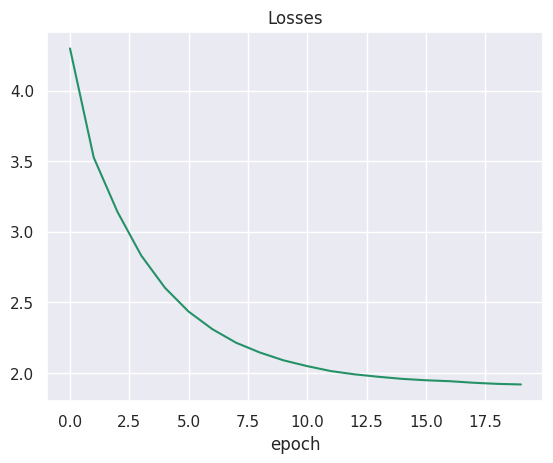

In [59]:
plt.plot(np.arange(len(losses)), losses)
plt.title("Losses")
plt.xlabel("epoch")
plt.show()

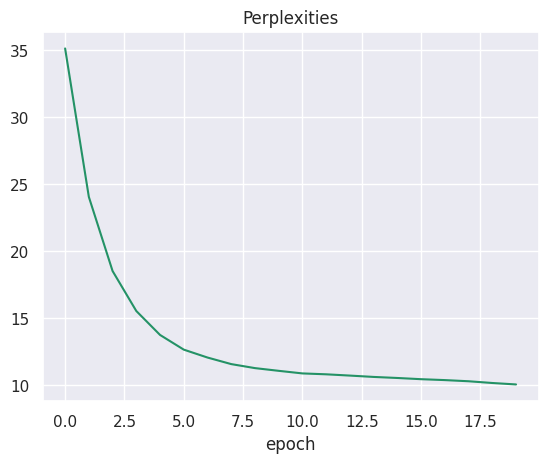

In [60]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title("Perplexities")
plt.xlabel("epoch")
plt.show()

In [61]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 128) -> str:
    device = 'cpu'
    model = model.to(device)

    words = starting_seq.split()

    input_ids = [word2ind['<bos>']] + [
        word2ind.get(word, word2ind['<unk>'])
        for word in words
    ]

    input_ids = torch.LongTensor(input_ids).to(device)

    model.eval()

    with torch.no_grad():
        for i in range(max_seq_len):
            next_word_distribution = model(input_ids)[-1]
            next_word = next_word_distribution.squeeze().argmax()

            input_ids = torch.cat([
                input_ids,
                next_word.unsqueeze(0)
            ])

            if next_word.item() == word2ind['<eos>']:
                break

    generated_words = [
        ind2word[idx.item()]
        for idx in input_ids
        if idx.item() not in {
            word2ind['<bos>'],
            word2ind['<eos>']
        }
    ]

    return ' '.join(generated_words)

In [62]:
generate_sequence(model, starting_seq='the best horror is ')

'the best horror is film .'

In [63]:
generate_sequence(model, starting_seq='the worst comedy is ')

'the worst comedy is ever .'

Первая генерация была осмысленной в каком то виде, по крайней мере предложение валидное. Но второе уже нет) Попробуем второй эксперимент и поиграться с гиперпараметрами и архитектуру изменить и попробовать ее сделать более сложной

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Усложним модель, сделаем более глубокую и сделаем скип коннекшоны

In [64]:
class ResidualGRUBlock(nn.Module):
  def __init__(self, hidden_dim):
    super().__init__()

    self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
    self.layerNorm = nn.LayerNorm(hidden_dim)
    self.layerNorm2 = nn.LayerNorm(hidden_dim)

    self.linear = nn.Linear(hidden_dim, hidden_dim)
    self.second_linear = nn.Linear(hidden_dim, hidden_dim)

    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(p=0.2)

  def forward(self, x):
    residual = x
    layers = self.layerNorm(x)
    output, _ = self.gru(layers)
    output = self.layerNorm2(output)
    linear = self.linear(output)
    relu = self.relu(linear)
    second_linear = self.second_linear(relu)
    output = self.dropout(second_linear) + residual

    return output

In [65]:
class LanguageModelV2(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)

        self.blocks = nn.ModuleList([
            ResidualGRUBlock(hidden_dim)
            for i in range(4)
        ])

        self.projection = nn.Linear(hidden_dim, vocab_size)


    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_batch)

        for block in self.blocks:
          x = block(x)

        return self.projection(x)

Добавим в трейн луп скедулер

In [66]:
def train_model(model, scheduler, train_dataloader, eval_dataloader, optimizer, criterion, num_epoch=20):
  losses, perplexities = [], []
  for epoch in range(num_epoch):
    epoch_losses = []
    model.train()
    for batch in tqdm(train_dataloader, desc=f'Training epoch: {epoch}:'):
      optimizer.zero_grad()
      logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
      loss = criterion(logits, batch['target_ids'].flatten())
      loss.backward()
      optimizer.step()

      epoch_losses.append(loss.item())

    losses.append(sum(epoch_losses) / len(epoch_losses))
    perplexities.append(evaluate(model, criterion, eval_dataloader))

    scheduler.step()

  return losses, perplexities

In [67]:
model = LanguageModelV2(hidden_dim=512, vocab_size=len(vocab)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
losses_v2, perplexities_v2 = train_model(model, scheduler, train_dataloader, eval_dataloader, optimizer, criterion)

Training epoch: 0::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 1::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 2::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 3::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 4::   0%|          | 0/181 [00:00<?, ?it/s]

...

Training epoch: 15::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 16::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 17::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 18::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch: 19::   0%|          | 0/181 [00:00<?, ?it/s]

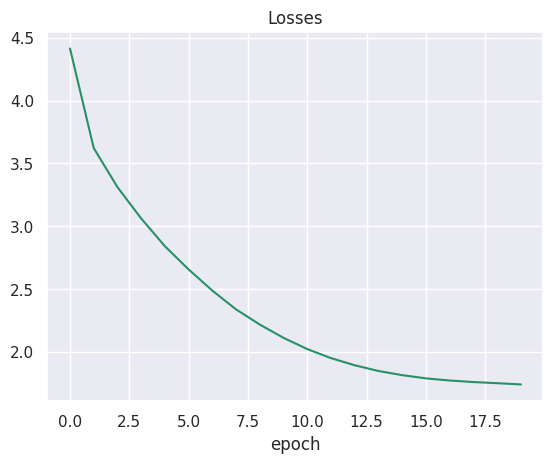

In [68]:
plt.plot(np.arange(len(losses_v2)), losses_v2)
plt.title("Losses")
plt.xlabel("epoch")
plt.show()

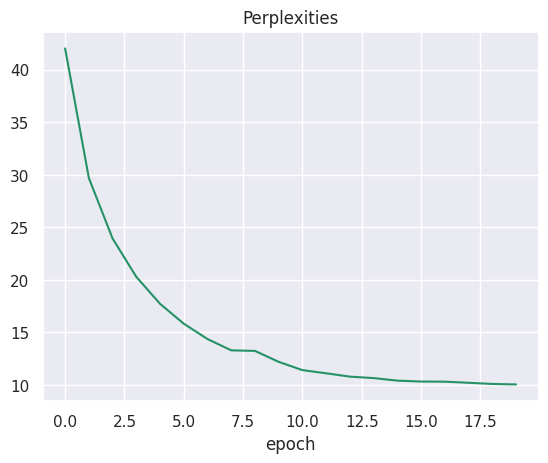

In [69]:
plt.plot(np.arange(len(perplexities_v2)), perplexities_v2)
plt.title("Perplexities")
plt.xlabel("epoch")
plt.show()

In [70]:
generate_sequence(model, starting_seq='the best horror is ')

'the best horror is exception .'

In [71]:
generate_sequence(model, starting_seq='the worst comedy is ')

'the worst comedy is hot .'

Ну тоже как и в первой модели, можно представить что в первой генерации название фильма exception. А вот вторая генерация так же не имеет никакого смысла)

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

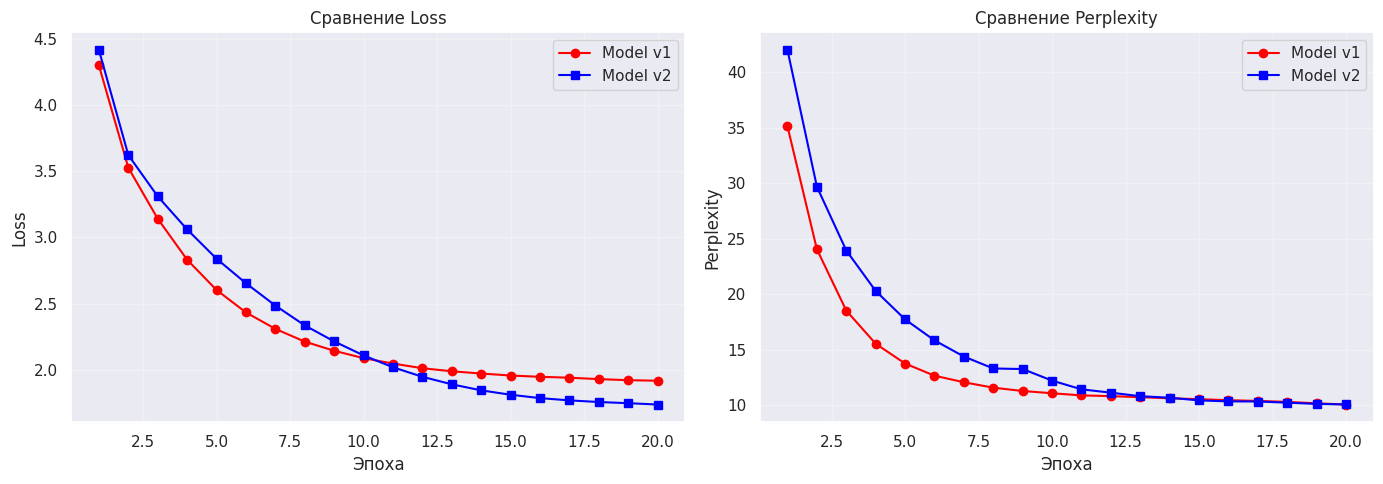

In [77]:
import matplotlib.pyplot as plt

epochs = range(1, len(losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, losses, marker='o', color='red', label='Model v1')
axes[0].plot(epochs, losses_v2, marker='s', color='blue', label='Model v2')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Сравнение Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, perplexities, marker='o', color='red', label='Model v1')
axes[1].plot(epochs, perplexities_v2, marker='s', color='blue', label='Model v2')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Сравнение Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [78]:
import pandas as pd

df = pd.DataFrame({
    'epoch': list(range(1, len(losses) + 1)),
    'loss_v1': losses,
    'loss_v2': losses_v2,
    'ppl_v1':  perplexities,
    'ppl_v2':  perplexities_v2,
})
df['loss_diff'] = df['loss_v2'] - df['loss_v1']
df['winner']    = np.where(df['loss_diff'] < 0, 'v2', 'v1')

display(df)

,epoch,loss_v1,loss_v2,ppl_v1,ppl_v2,loss_diff,winner
0,1,4.298245,4.414716,35.140237,42.023605,0.116471,v1
1,2,3.526141,3.621606,24.053658,29.698952,0.095464,v1
2,3,3.141073,3.309961,18.518652,23.941631,0.168888,v1
3,4,2.831760,3.060452,15.531627,20.293314,0.228692,v1
4,5,2.603178,2.839245,13.745014,17.728743,0.236067,v1
5,6,2.433958,2.654242,12.647152,15.833701,0.220284,v1
6,7,2.309588,2.485745,12.057139,14.376105,0.176157,v1
7,8,2.213452,2.335973,11.567042,13.299381,0.122521,v1
8,9,2.144305,2.215068,11.267276,13.247975,0.070764,v1
9,10,2.088677,2.109361,11.064530,12.204329,0.020684,v1


In [82]:
def compare_models(losses_a, losses_b, ppl_a, ppl_b, name_a='v1', name_b='v2'):
    k = min(3, len(losses_a))
    avg_a = np.mean(losses_a[-k:])
    avg_b = np.mean(losses_b[-k:])

    print(f"Средний loss за последние {k} эпох:")
    print(f"  {name_a}: {avg_a:.4f}")
    print(f"  {name_b}: {avg_b:.4f}")

    diff = avg_b - avg_a
    rel = abs(diff) / avg_a * 100

    if abs(diff) < 1e-3:
        print("➡ Модели практически одинаковы.")
    elif diff < 0:
        print(f"Модель {name_b} лучше на {abs(diff):.4f} ({rel:.2f}%).")
    else:
        print(f"Модель {name_a} лучше на {abs(diff):.4f} ({rel:.2f}%).")

    ppl_avg_a = np.mean(ppl_a[-k:])
    ppl_avg_b = np.mean(ppl_b[-k:])
    print(f"\nPerplexity: {name_a}={ppl_avg_a:.2f}, {name_b}={ppl_avg_b:.2f}")
    print(f"Меньшая PPL (лучше): "
          f"{name_a if ppl_avg_a < ppl_avg_b else name_b}")

compare_models(losses, losses_v2, perplexities, perplexities_v2)

Средний loss за последние 3 эпох:
  v1: 1.9234
  v2: 1.7481
Модель v2 лучше на 0.1754 (9.12%).

Perplexity: v1=10.16, v2=10.12
Меньшая PPL (лучше): v2


Собственно еще по графикам первым в сравнении было видно что по лоссу выигрывает вторая модель у которой был скедулер и в целом был скип коннекшон добавлен и 4 слоя. Она более глубокая и сложная, что нам дало улучшение на 9+ процентов. По Перплексити на графике не видно явно кто лучше, хотя на первых 10и эпохах первая модель выигрывала.

Можно ли назвать вторую модель как сильную, конечно нет, она тоже очень слабая, в целом можно накинуть еще больше слоев и посмотреть как будет.

В целом задача я считаю решена, попробованы несколько подходов, простой бейслайн и второй где мы добавили скип коннекшоны, лр поменяли, добавили скедулер. Но я уже повторяюсь